In [11]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv('spambase.data')
df.head()

,0,0.64,0.64.1,0.1,0.32,0.2,0.3,0.4,0.5,0.6,...,0.41,0.42,0.43,0.778,0.44,0.45,3.756,61,278,1
0,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
1,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
2,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,1.85,0.00,0.00,1.85,0.00,0.00,...,0.00,0.223,0.0,0.000,0.000,0.000,3.000,15,54,1


In [12]:
X = df.iloc[:, :-1]
Y = df.iloc[:, -1]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

model = LogisticRegression()
model.fit(X_train, Y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [13]:
k_values = [1,3,5,7,9,11]

results = []

for k in k_values:
    
    knn = KNeighborsClassifier(n_neighbors=k)
    
    scores = cross_val_score(knn, X_train, Y_train, cv=5, scoring='accuracy')
    
    accuracy = scores.mean()
    error = 1 - accuracy
    
    results.append((k, accuracy, error))
    
    print(f"k={k}")
    print("Validation Accuracy:", accuracy)
    print("Validation Error:", error)
    print()


k=1
Validation Accuracy: 0.8081159420289854
Validation Error: 0.1918840579710146

k=3
Validation Accuracy: 0.8028985507246376
Validation Error: 0.19710144927536244

k=5
Validation Accuracy: 0.8081159420289856
Validation Error: 0.19188405797101438

k=7
Validation Accuracy: 0.8014492753623188
Validation Error: 0.1985507246376812

k=9
Validation Accuracy: 0.7947826086956521
Validation Error: 0.2052173913043479

k=11
Validation Accuracy: 0.7927536231884058
Validation Error: 0.2072463768115942



In [14]:
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, Y_train)

LinearDiscriminantAnalysis()

In [15]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, Y_train)

KNeighborsClassifier()

In [16]:
def evaluate_model(model, X, y):

    y_pred = model.predict(X)

    accuracy = accuracy_score(y, y_pred)
    error = 1 - accuracy
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)

    return accuracy, error, precision, recall


In [17]:
models = {
    "Logistic Regression": model,
    "LDA": lda_model,
    "kNN": knn_model
}

print("Training Performance\n")

for name, model in models.items():

    acc, err, prec, rec = evaluate_model(model, X_train, Y_train)

    print(name)
    print("Accuracy:", acc)
    print("Error:", err)
    print("Precision:", prec)
    print("Recall:", rec)
    print()


Training Performance

Logistic Regression
Accuracy: 0.9272463768115942
Error: 0.07275362318840584
Precision: 0.9095022624434389
Recall: 0.9020194465220643

LDA
Accuracy: 0.8918840579710144
Error: 0.10811594202898556
Precision: 0.9191304347826087
Recall: 0.7905759162303665

kNN
Accuracy: 0.8710144927536232
Error: 0.1289855072463768
Precision: 0.8420245398773006
Recall: 0.8212415856394913



In [18]:
print("Testing Performance\n")

for name, model in models.items():

    acc, err, prec, rec = evaluate_model(model, X_test, Y_test)

    print(name)
    print("Accuracy:", acc)
    print("Error:", err)
    print("Precision:", prec)
    print("Recall:", rec)
    print()


Testing Performance

Logistic Regression
Accuracy: 0.908695652173913
Error: 0.09130434782608698
Precision: 0.9057017543859649
Recall: 0.8694736842105263

LDA
Accuracy: 0.8773913043478261
Error: 0.12260869565217392
Precision: 0.9175
Recall: 0.7726315789473684

kNN
Accuracy: 0.7678260869565218
Error: 0.23217391304347823
Precision: 0.7352941176470589
Recall: 0.6842105263157895



The Logistic Regression model has the most accuracy, but its precision is not the best. LDA has the best precision. kNN performs the worst with low accuracy, high error, low precision, and low recall. Logistic Regression would be the best model because it has the lowest error, highest precision, and highest recall.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


AUC: 0.8465762183235869


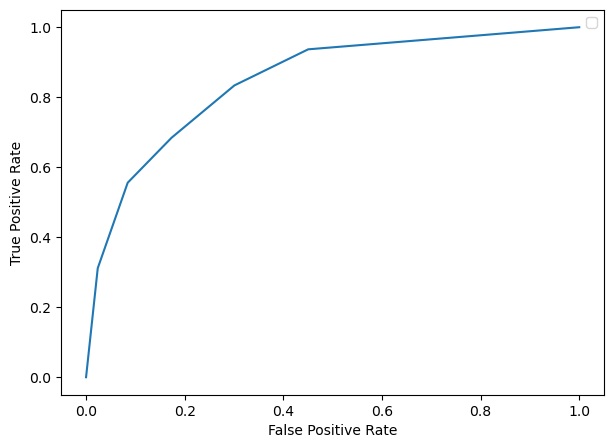

In [21]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = model.predict_proba(X_test)[:, 1]

fpr_pkg, tpr_pkg, thresholds_pkg = roc_curve(Y_test, y_prob)

roc_auc = auc(fpr_pkg, tpr_pkg)
print("AUC:", roc_auc)

plt.figure(figsize=(7,5))
plt.plot(fpr_pkg, tpr_pkg)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

thresholds = np.arange(0, 1.1, 0.1)

manual_fpr = []
manual_tpr = []

y_prob = model.predict_proba(X_test)[:, 1]

for T in thresholds:
    y_pred_T = (y_prob >= T).astype(int)

    tn, fp, fn, tp = confusion_matrix(Y_test, y_pred_T).ravel()

    tpr = tp / (tp + fn)   
    fpr = fp / (fp + tn)

    manual_tpr.append(tpr)
    manual_fpr.append(fpr)

    print(f"Threshold = {T:.1f}")
    print(f"FPR = {fpr:.4f}, TPR = {tpr:.4f}")
    print()

Threshold = 0.0
FPR = 1.0000, TPR = 1.0000

Threshold = 0.1
FPR = 0.4504, TPR = 0.9368

Threshold = 0.2
FPR = 0.4504, TPR = 0.9368

Threshold = 0.3
FPR = 0.3007, TPR = 0.8337

Threshold = 0.4
FPR = 0.3007, TPR = 0.8337

Threshold = 0.5
FPR = 0.1733, TPR = 0.6842

Threshold = 0.6
FPR = 0.0844, TPR = 0.5558

Threshold = 0.7
FPR = 0.0844, TPR = 0.5558

Threshold = 0.8
FPR = 0.0844, TPR = 0.5558

Threshold = 0.9
FPR = 0.0237, TPR = 0.3116

Threshold = 1.0
FPR = 0.0237, TPR = 0.3116



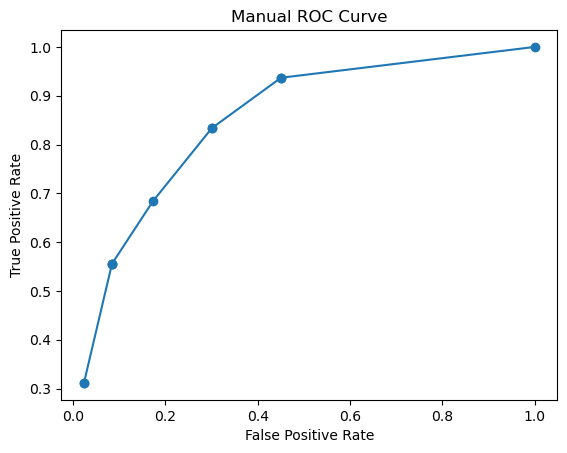

In [25]:
plt.plot(manual_fpr, manual_tpr, marker='o')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Manual ROC Curve")
plt.show()

The differences are the package curve is smoother, while the manual one is more jagged. The manual one also has significantly less threshold points, so the package curve is a lot more precise. To make them more similar, you can increase the number of thresholds on the manual curve.